# Image background occlusion

In this notebook we explore the effects of bluring the background/non-person content of images containing persons. The goal is to see if we observe changes in regional variance in both the latent representations as well as the fMRI reconstructions. Identifying regions of low variance across this task would tentatively relate those regions to the unblured, person-containing image section. From a neuro-scientifical viewpoint this is especially related to the "bodies" and "faces" selective regions, which we would assume to be linked to this aspect. Very broadly speaking, the experiment setup is similar to the fLoc bodies experiment, with the difference being that the target class (person) is extracted from its natural context in the image rather than artificially placed in gray scale on a gray noise background.

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np

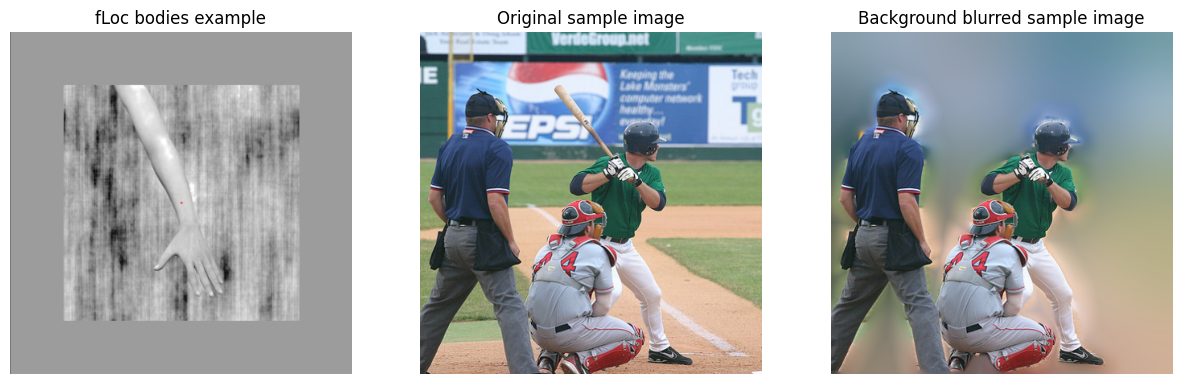

In [3]:
# Show some images images contextualising the experiment background
floc_img = plt.imread("fLoc_bodies_example.png")
sample_img = plt.imread("/u/fdammeier/repositories/NeuroFlow/sample_data/classified/310person/6.png")
sample_blured_img = plt.imread("/u/fdammeier/repositories/NeuroFlow/sample_data/classified/310person_blured/6.png")

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(floc_img)
plt.title("fLoc bodies example")
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(sample_img)
plt.title("Original sample image")
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(sample_blured_img)
plt.title("Background blurred sample image")
plt.axis('off')
plt.show()


# Variance visualizations (aggregate)

In [4]:
original_img_embeddings = torch.load("/u/fdammeier/artifacts/310person/image_embeddings.pt")
blured_img_embeddings = torch.load("/u/fdammeier/artifacts/310person_blur/image_embeddings.pt")

original_neurovae_embeddings = torch.load("/u/fdammeier/artifacts/310person/neurovae_embeddings_from_img.pt")
blured_neurovae_embeddings = torch.load("/u/fdammeier/artifacts/310person_blur/neurovae_embeddings_from_img.pt")

original_fmri_recons = torch.load("/u/fdammeier/artifacts/310person/reconstructed_fmri.pt").mean(dim=1)
blured_fmri_recons = torch.load("/u/fdammeier/artifacts/310person_blur/reconstructed_fmri.pt").mean(dim=1)

In [5]:
def plot_matrix_side_by_side(matrix1, matrix2, title1="Matrix 1", title2="Matrix 2", suptitle=None, cmap="viridis"):
    vmax = max(matrix1.max(), matrix2.max())
    vmin = min(matrix1.min(), matrix2.min())
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    im1 = axes[0].imshow(matrix1, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[0].set_title(title1)
    fig.colorbar(im1, ax=axes[0])
    im2 = axes[1].imshow(matrix2, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[1].set_title(title2)
    fig.colorbar(im2, ax=axes[1])
    if suptitle is not None:
        fig.suptitle(suptitle)
    plt.show()

def plot_histograms_side_by_side(data1, data2, bins=50, title1="Data 1", title2="Data 2", suptitle=None):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # use same bins for both histograms
    combined_data = np.concatenate([data1.flatten(), data2.flatten()])
    bins = np.histogram_bin_edges(combined_data, bins=bins)
    axes[0].hist(data1.flatten(), bins=bins)
    axes[0].set_title(title1)
    axes[0].set_xlim(bins[0], bins[-1])
    axes[1].hist(data2.flatten(), bins=bins)
    axes[1].set_title(title2)
    axes[1].set_xlim(bins[0], bins[-1])
    if suptitle is not None:
        fig.suptitle(suptitle)
    plt.show()

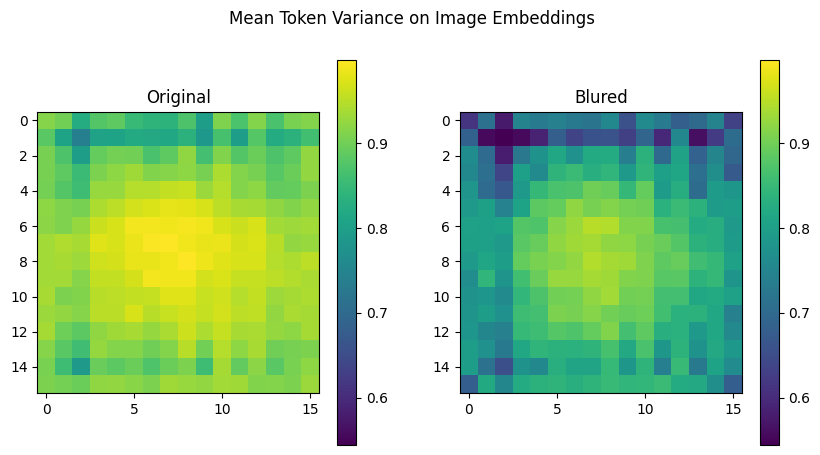

In [5]:
mean_token_var_original = original_img_embeddings.var(dim=0).mean(dim=-1).reshape(16, 16)
mean_token_var_blured = blured_img_embeddings.var(dim=0).mean(dim=-1).reshape(16, 16)

plot_matrix_side_by_side(
    mean_token_var_original.cpu().numpy(),
    mean_token_var_blured.cpu().numpy(),
    title1="Original", title2="Blured", 
    suptitle="Mean Token Variance on Image Embeddings"
)

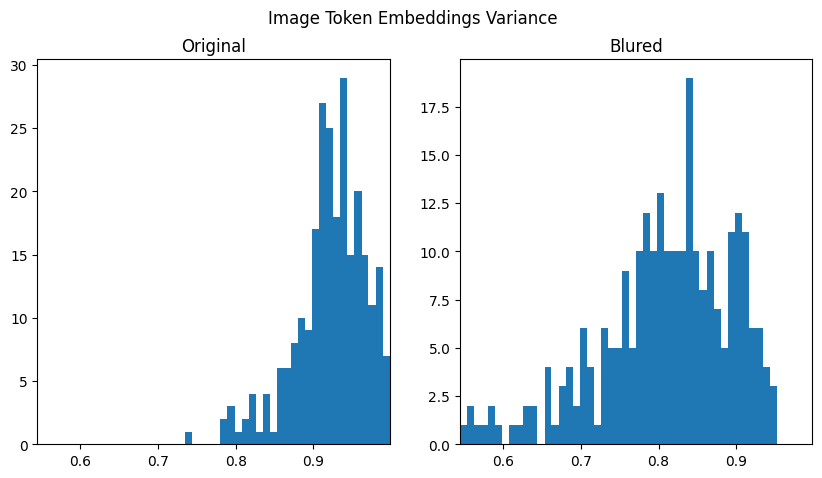

In [11]:
plot_histograms_side_by_side(
    mean_token_var_original.flatten().cpu().numpy(),
    mean_token_var_blured.flatten().cpu().numpy(),
    title1="Original",
    title2="Blured",
    suptitle="Image Token Embeddings Variance"
)

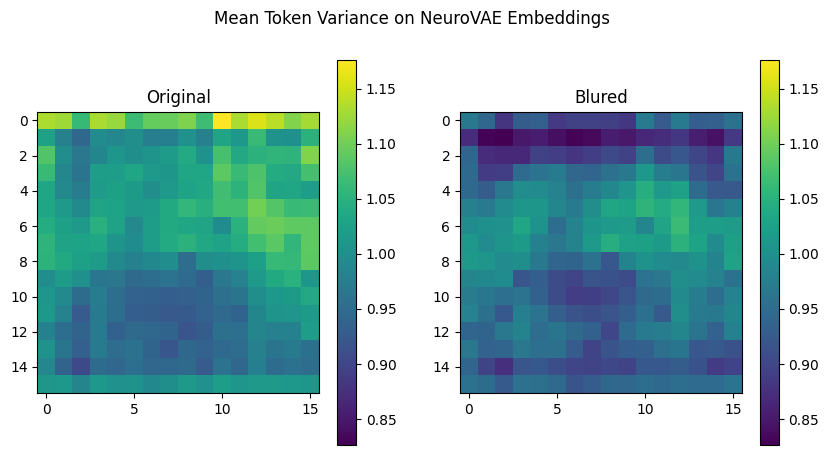

In [13]:
mean_token_var_original_neurovae = original_neurovae_embeddings.var(dim=0).mean(dim=-1).reshape(16, 16)
mean_token_var_blured_neurovae = blured_neurovae_embeddings.var(dim=0).mean(dim=-1).reshape(16, 16)

plot_matrix_side_by_side(
    mean_token_var_original_neurovae.cpu().numpy(),
    mean_token_var_blured_neurovae.cpu().numpy(),
    title1="Original", title2="Blured", 
    suptitle="Mean Token Variance on NeuroVAE Embeddings"
)   

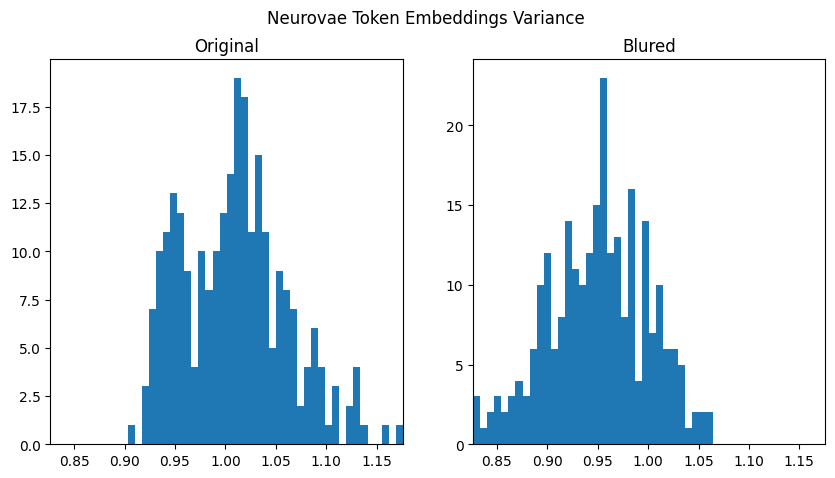

In [14]:
plot_histograms_side_by_side(
    mean_token_var_original_neurovae.flatten().cpu().numpy(),
    mean_token_var_blured_neurovae.flatten().cpu().numpy(),
    title1="Original",
    title2="Blured",
    suptitle="Neurovae Token Embeddings Variance"
)

In [15]:
original_cls_embeddings = torch.load("/u/fdammeier/artifacts/310person/cls_embeddings.pt")
blured_cls_embeddings = torch.load("/u/fdammeier/artifacts/310person_blur/cls_embeddings.pt")

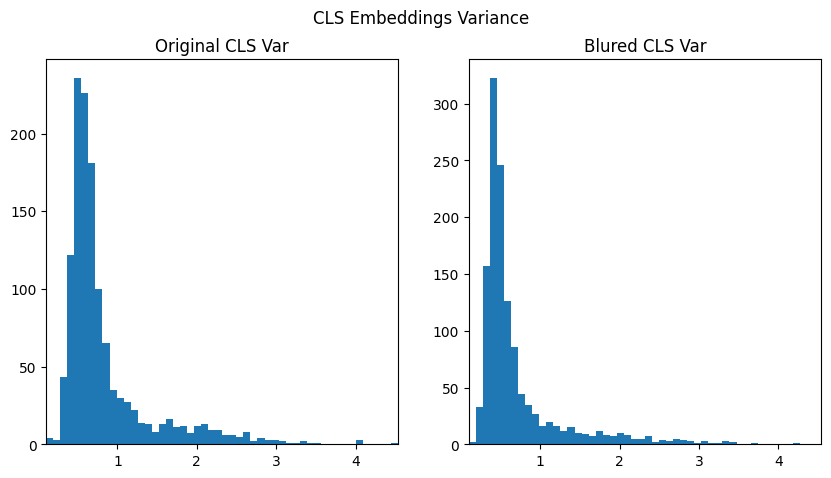

In [16]:
original_cls_var = original_cls_embeddings.var(dim=0)
blured_cls_var = blured_cls_embeddings.var(dim=0)

plot_histograms_side_by_side(
    original_cls_var.cpu().numpy(),
    blured_cls_var.cpu().numpy(),
    title1="Original CLS Var",
    title2="Blured CLS Var",
    suptitle="CLS Embeddings Variance"
)

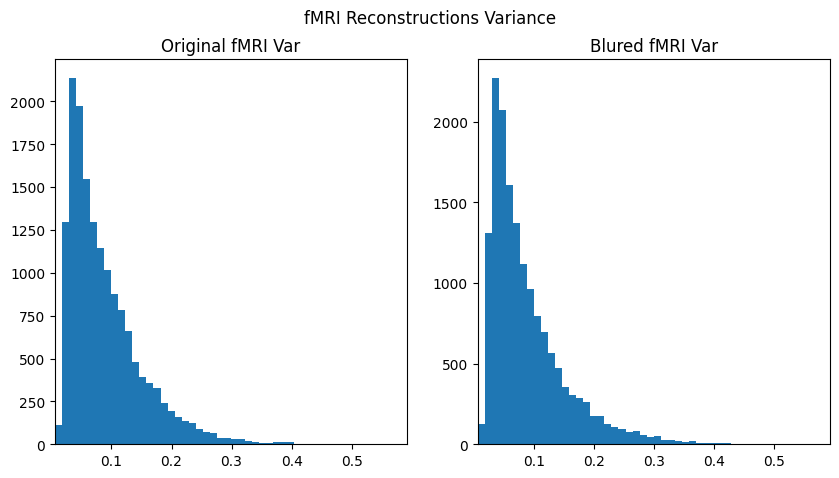

In [17]:
original_fmri_var = original_fmri_recons.var(dim=0)
blured_fmri_var = blured_fmri_recons.var(dim=0)

plot_histograms_side_by_side(
    original_fmri_var.cpu().numpy(),
    blured_fmri_var.cpu().numpy(),
    title1="Original fMRI Var",
    title2="Blured fMRI Var",
    suptitle="fMRI Reconstructions Variance"
)

# Visualizations (single example)

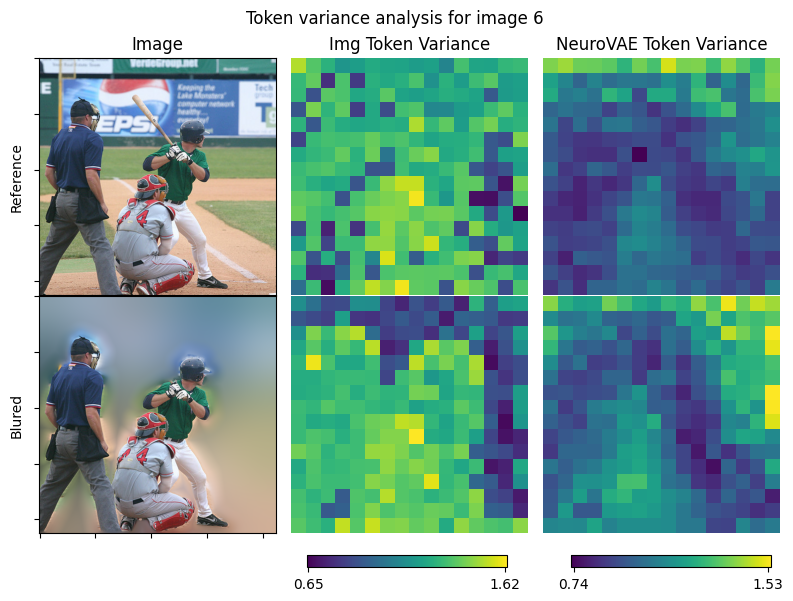

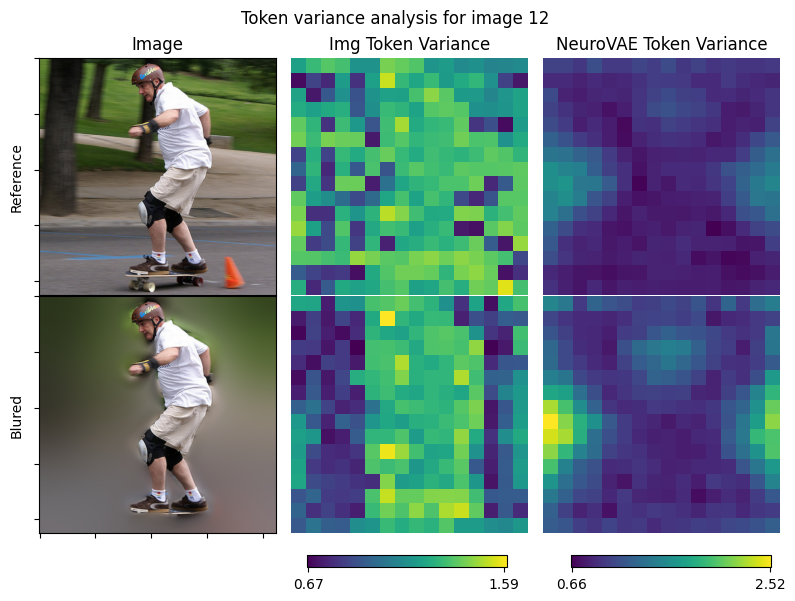

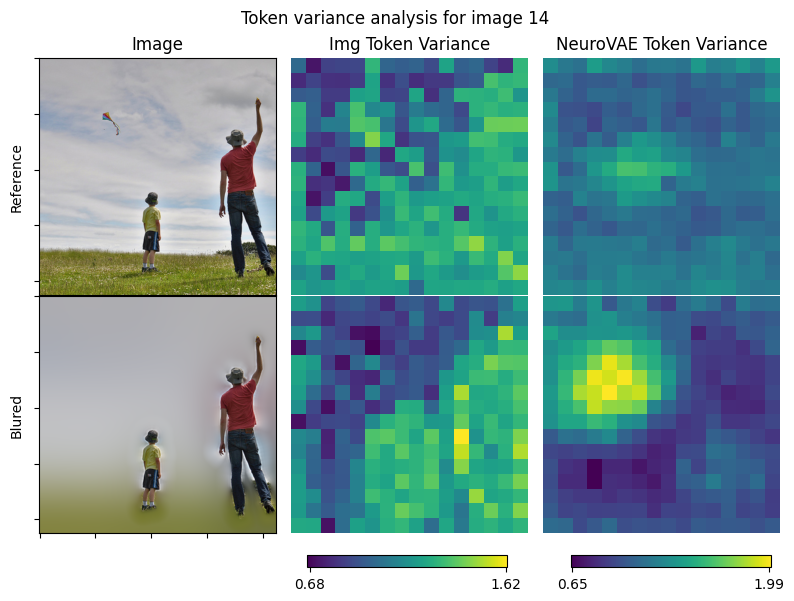

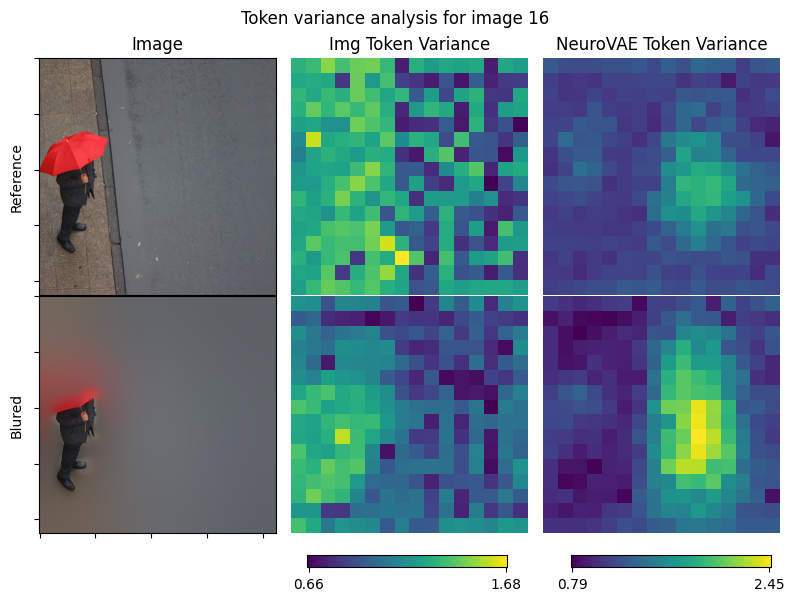

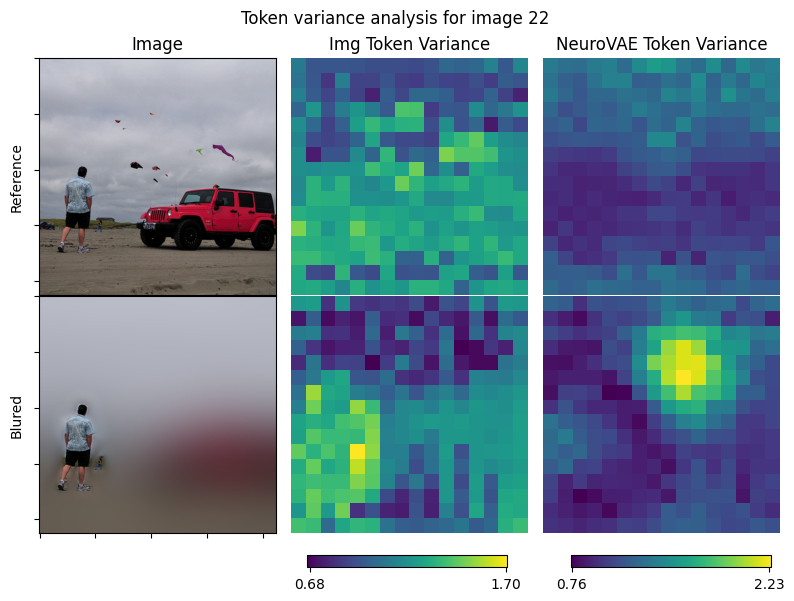

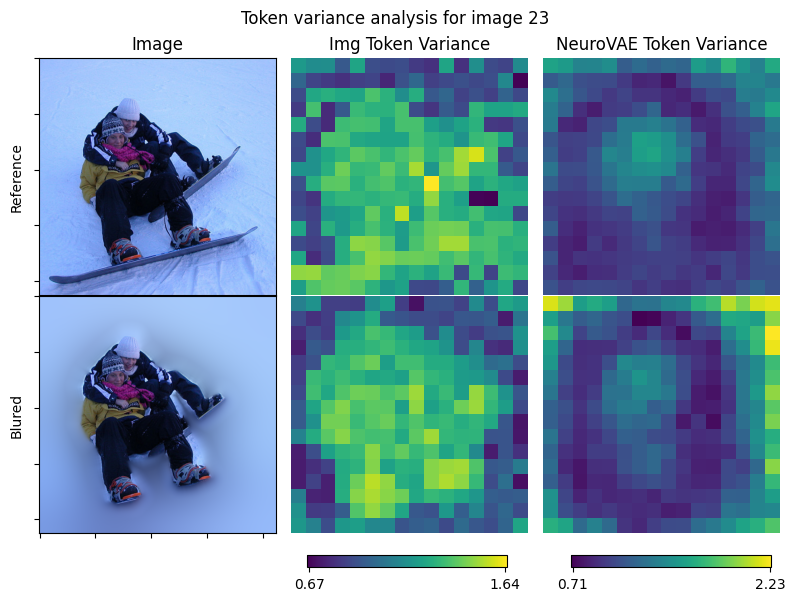

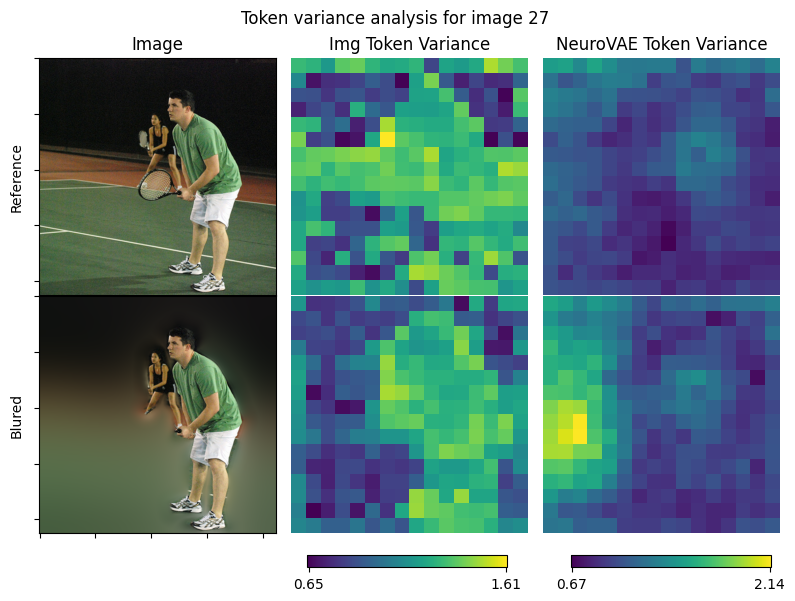

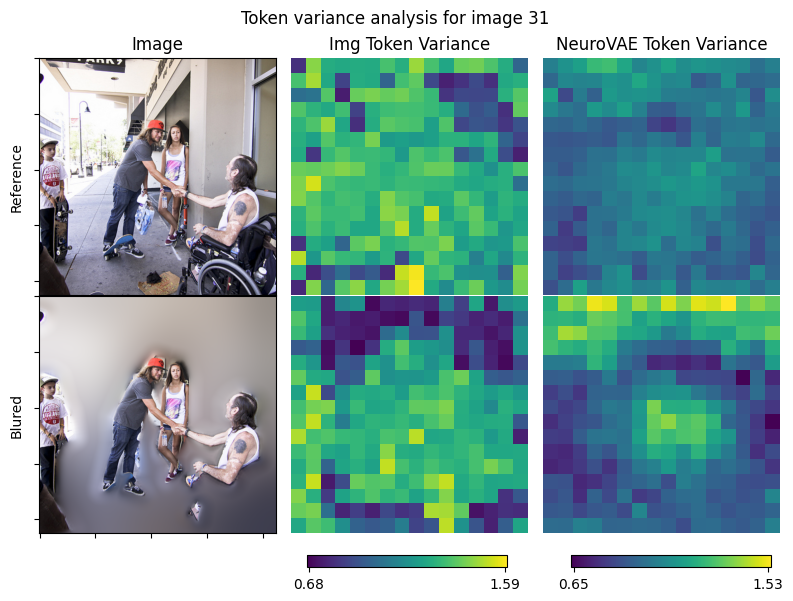

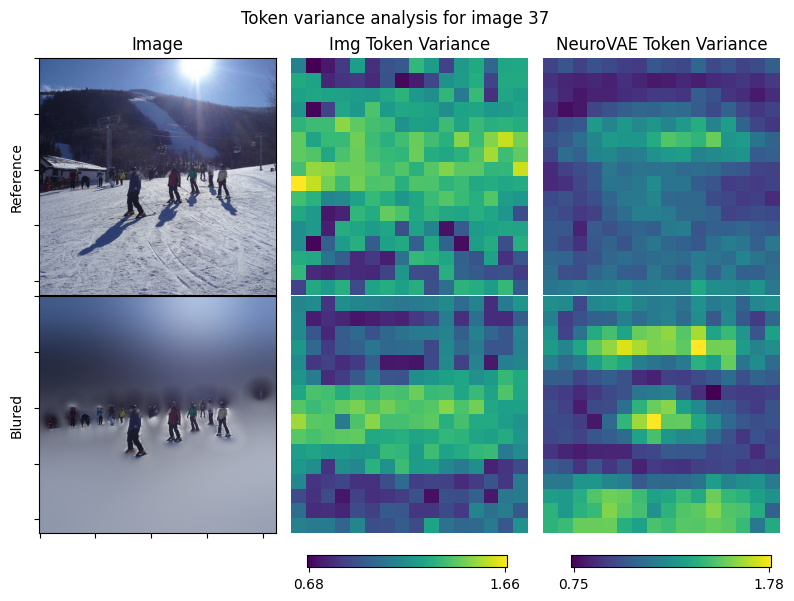

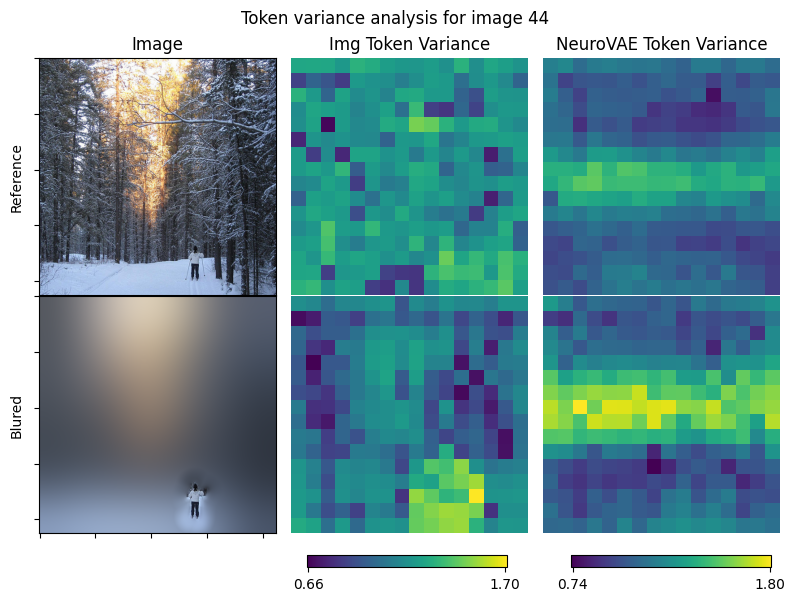

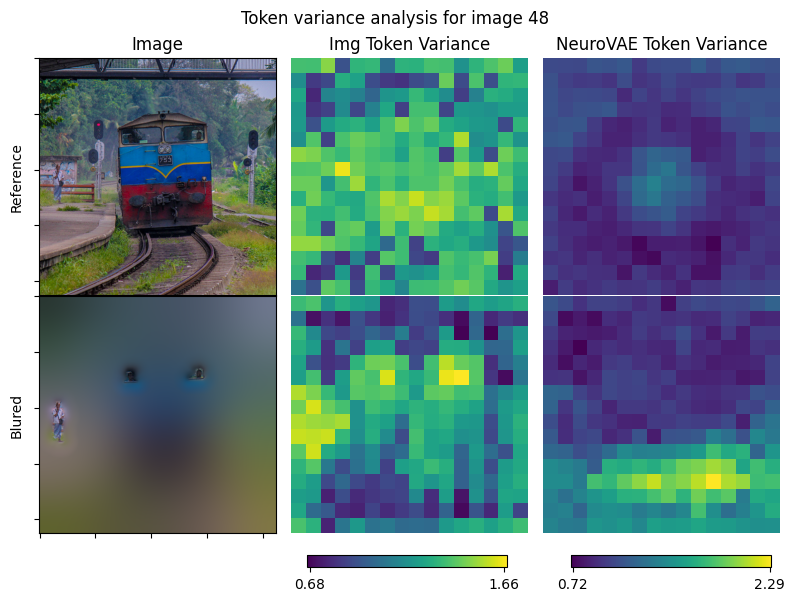

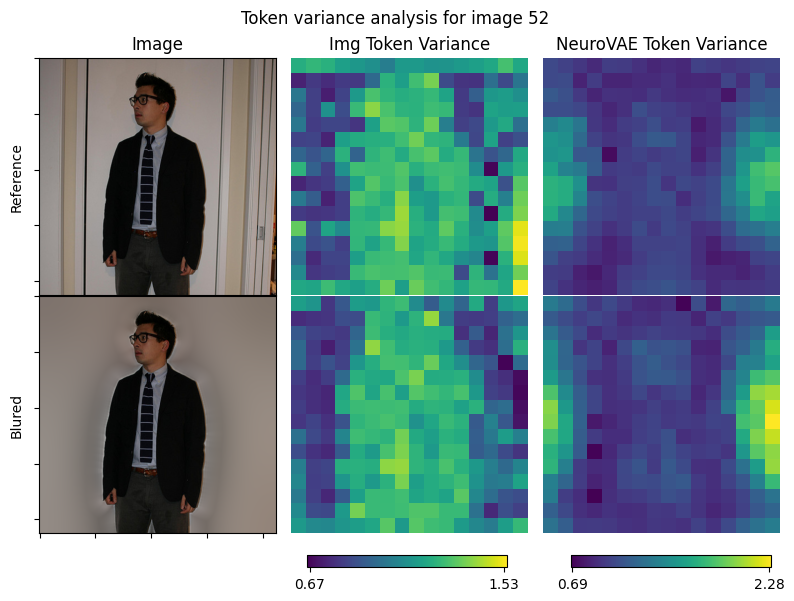

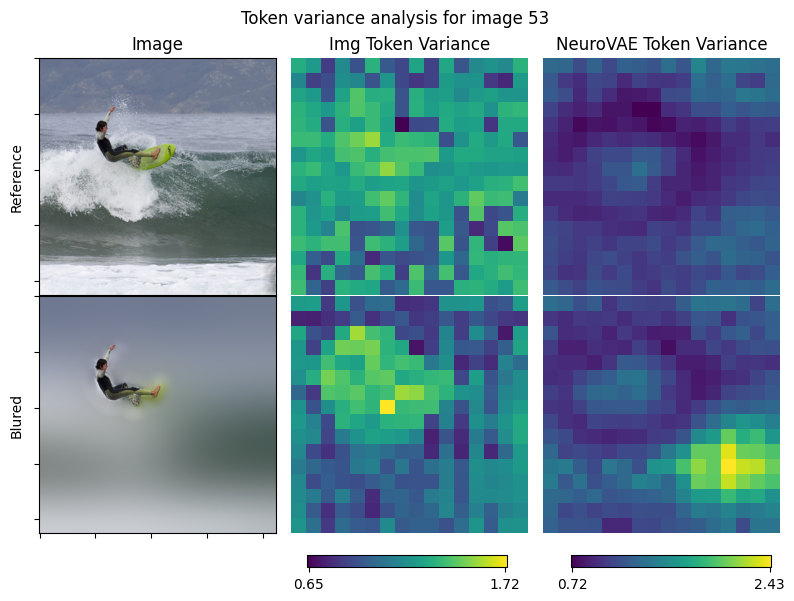

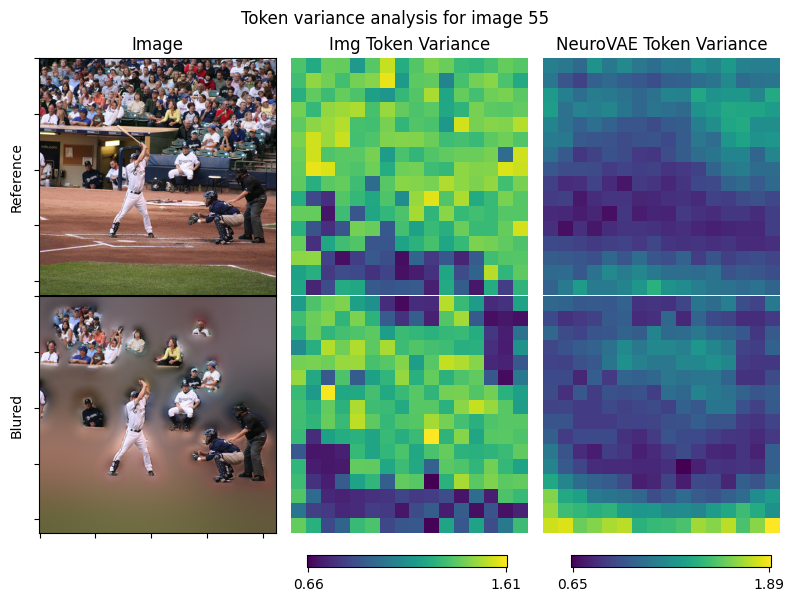

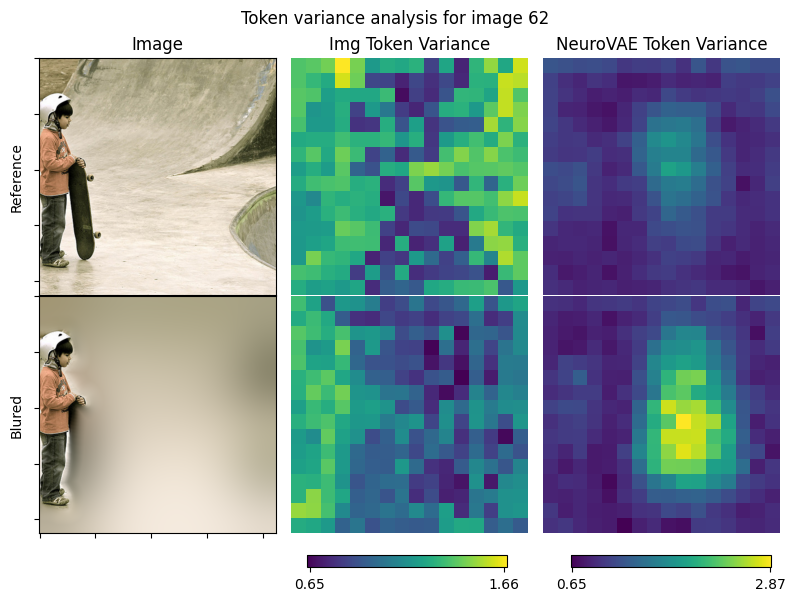

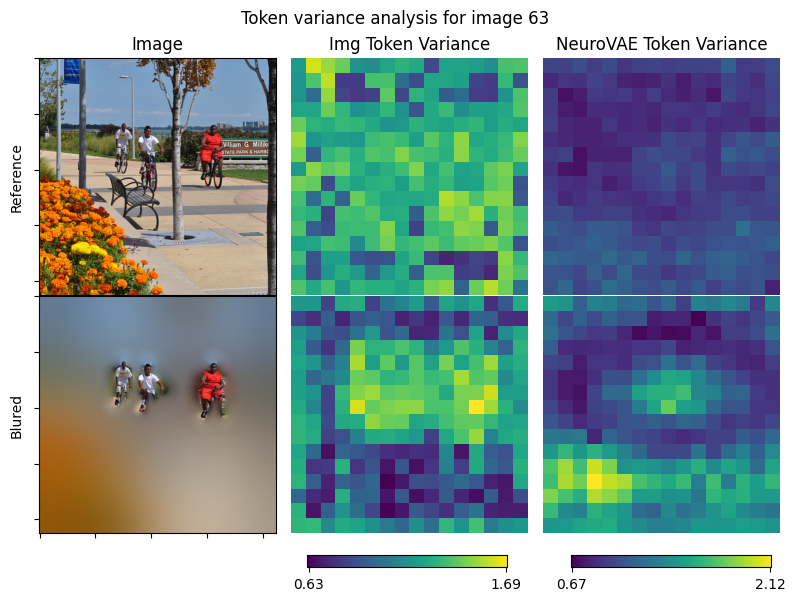

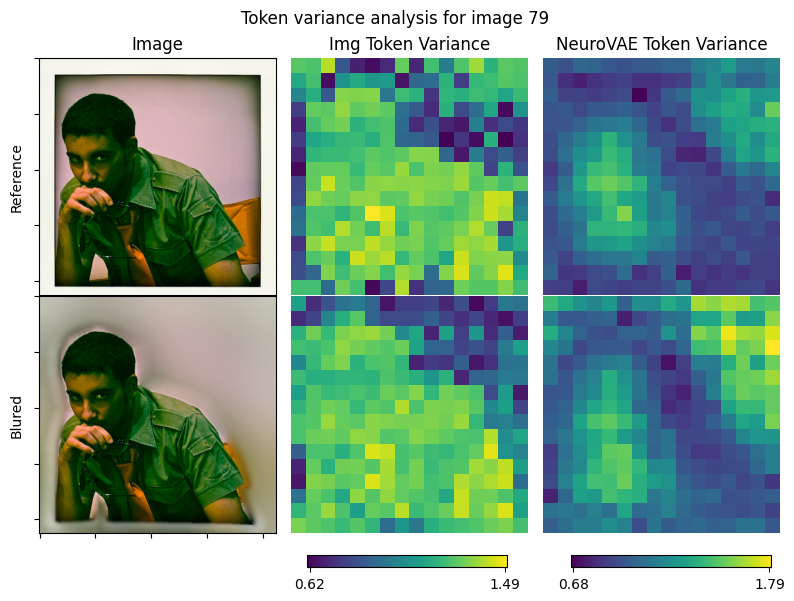

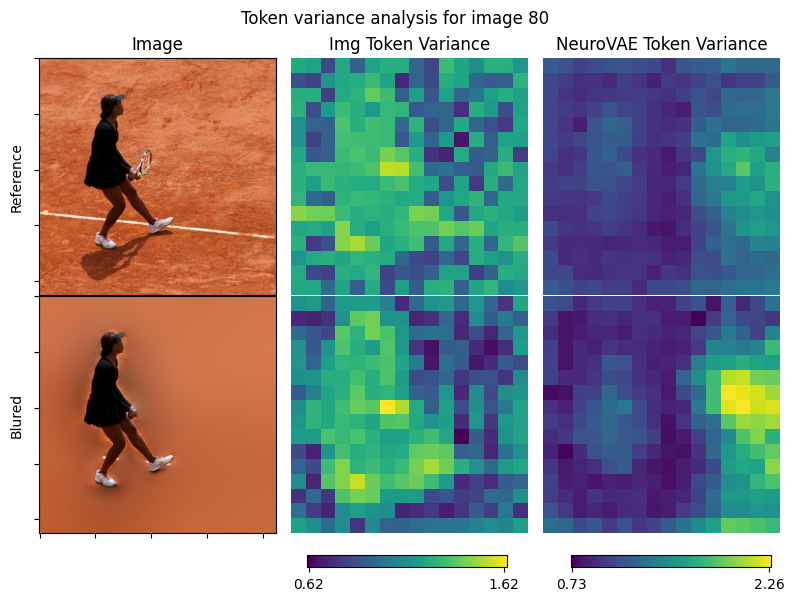

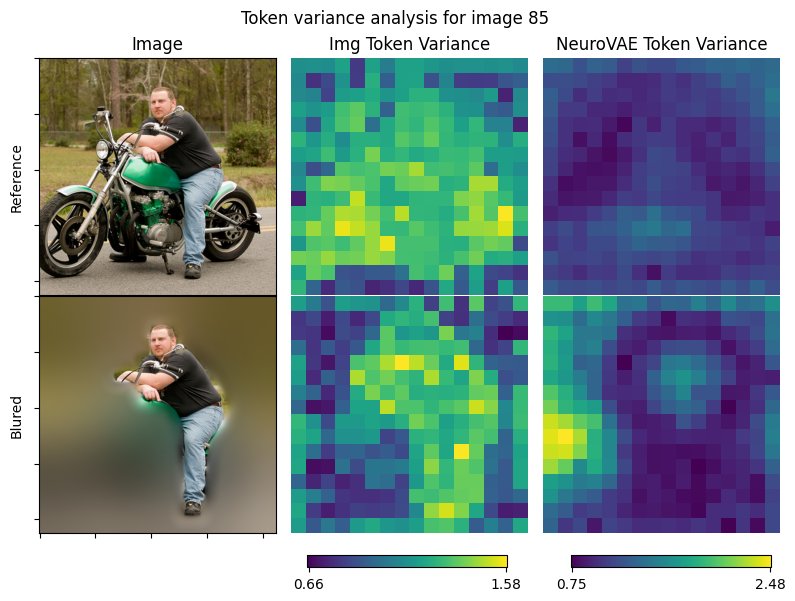

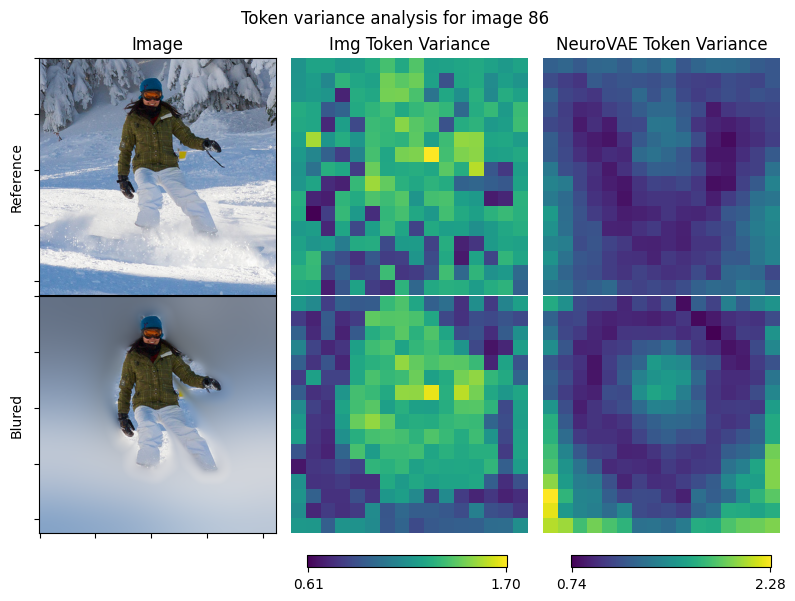

In [78]:
import os

image_ids = sorted([int(img_name.split('.')[0]) for img_name in os.listdir('/u/fdammeier/repositories/NeuroFlow/sample_data/classified/310person')])

sample = 0



# plot_matrix_side_by_side(vae_token_var_original, vae_token_var_blured, title1="Original VAE", title2="Blured VAE", suptitle="NeuroVAE Token Variance")

for i, image_idx in enumerate(image_ids[:20]):
    img_token_var_original = original_img_embeddings[i].var(dim=-1).reshape(16, 16)
    img_token_var_blured = blured_img_embeddings[i].var(dim=-1).reshape(16, 16)

    vae_token_var_original = original_neurovae_embeddings[i].var(dim=-1).reshape(16, 16)
    vae_token_var_blured = blured_neurovae_embeddings[i].var(dim=-1).reshape(16, 16)

    img_orig = plt.imread(f'/u/fdammeier/repositories/NeuroFlow/sample_data/classified/310person/{image_idx}.png')
    img_blured = plt.imread(f'/u/fdammeier/repositories/NeuroFlow/sample_data/classified/310person_blured/{image_idx}.png')

    fig, axes = plt.subplots(2, 3, figsize=(8, 6))

    # Images
    axes[0][0].imshow(img_orig)
    axes[0][0].set_xticklabels([])
    axes[0][0].set_yticklabels([])
    axes[0][0].set_ylabel('Reference')
    axes[0][0].set_title('Image')
    axes[1][0].imshow(img_blured)
    axes[1][0].set_xticklabels([])
    axes[1][0].set_yticklabels([])
    axes[1][0].set_ylabel('Blured')

    # Img token variance
    vmax_img = max(img_token_var_original.max(), img_token_var_blured.max())
    vmin_img = min(img_token_var_original.min(), img_token_var_blured.min())
    axes[0][1].imshow(img_token_var_original, cmap='viridis', vmax=vmax_img, vmin=vmin_img)
    axes[0][1].axis('off')
    axes[0][1].set_title('Img Token Variance')

    im_img = axes[1][1].imshow(img_token_var_blured, cmap='viridis', vmax=vmax_img, vmin=vmin_img)
    axes[1][1].axis('off')

    # VAE token variance
    vmax_vae = max(vae_token_var_original.max(), vae_token_var_blured.max())
    vmin_vae = min(vae_token_var_original.min(), vae_token_var_blured.min())
    axes[0][2].imshow(vae_token_var_original, cmap='viridis', vmax=vmax_vae, vmin=vmin_vae)
    axes[0][2].axis('off')
    axes[0][2].set_title('NeuroVAE Token Variance')

    im_vae = axes[1][2].imshow(vae_token_var_blured, cmap='viridis', vmax=vmax_vae, vmin=vmin_vae)
    axes[1][2].axis('off')
    
    plt.suptitle(f"Token variance analysis for image {image_idx}")
    
    plt.tight_layout()
    fig.subplots_adjust(bottom=0.1)
    cbar1_ax = fig.add_axes([0.39, 0.05, 0.25, 0.02])
    fig.colorbar(im_img, cax=cbar1_ax, location='bottom', ticks=[round(vmin_img.item(), 2)+0.01, round(vmax_img.item(), 2)-0.01])
    cbar2_ax = fig.add_axes([0.72, 0.05, 0.25, 0.02])
    fig.colorbar(im_vae, cax=cbar2_ax, location='bottom', ticks=[round(vmin_vae.item(), 2)+0.01, round(vmax_vae.item(), 2)-0.01])

    plt.show()

# PCA

In [38]:
def pca(X: torch.Tensor, n_components: int) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    original_dtype = X.dtype
    # SVD is not supported for half-precision on CPU — upcast temporarily
    if X.dtype in (torch.float16, torch.bfloat16):
        X = X.float()

    mean = X.mean(dim=0)
    X_centered = X - mean

    U, S, Vh = torch.linalg.svd(X_centered, full_matrices=False)

    components = Vh[:n_components]
    X_pca = X_centered @ components.T

    variance = (S ** 2) / (len(X) - 1)
    explained_variance_ratio = variance[:n_components] / variance.sum()

    # Cast outputs back to the original dtype
    return X_pca.to(original_dtype), components.to(original_dtype), explained_variance_ratio.to(original_dtype)

def plot_cumulative_variance(
        explained_variance_ratio1: torch.Tensor, 
        explained_variance_ratio2: torch.Tensor, 
        title1: str = "Original", title2: str = "Blured", 
        suptitle: str = "Cumulative Explained Variance"
    ) -> None:
    cum_var1 = torch.cumsum(explained_variance_ratio1, dim=0)
    cum_var2 = torch.cumsum(explained_variance_ratio2, dim=0)

    plt.figure(figsize=(10, 5))
    plt.plot(cum_var1.cpu().numpy(), label=title1)
    plt.plot(cum_var2.cpu().numpy(), label=title2)
    plt.xlabel("Number of Components")
    plt.ylabel("Cumulative Explained Variance")
    plt.title(suptitle)
    plt.legend()
    plt.show()

def plot_first_two_components(
        X_pca1: torch.Tensor, X_pca2: torch.Tensor,
        title1: str = "Original", title2: str = "Blured", 
        suptitle: str = "First Two PCA Components"
    ) -> None:
    plt.figure(figsize=(10, 5))
    vmax = max(X_pca1[:, 0].max(), X_pca1[:, 1].max(), X_pca2[:, 0].max(), X_pca2[:, 1].max())
    vmin = min(X_pca1[:, 0].min(), X_pca1[:, 1].min(), X_pca2[:, 0].min(), X_pca2[:, 1].min())

    plt.scatter(X_pca1[:, 0].cpu().numpy(), X_pca1[:, 1].cpu().numpy(), label=title1, alpha=0.5)
    plt.scatter(X_pca2[:, 0].cpu().numpy(), X_pca2[:, 1].cpu().numpy(), label=title2, alpha=0.5)
    plt.xlim(vmin*1.1, vmax*1.1)
    plt.ylim(vmin*1.1, vmax*1.1)
    plt.xlabel("First Component")
    plt.ylabel("Second Component")
    plt.title(suptitle)
    plt.legend()
    plt.show()

In [25]:
cls_orig_pca, cls_orig_comp, cls_orig_evr = pca(original_cls_embeddings, n_components=50)
cls_blured_pca, cls_blured_comp, cls_blured_evr = pca(blured_cls_embeddings, n_components=50)

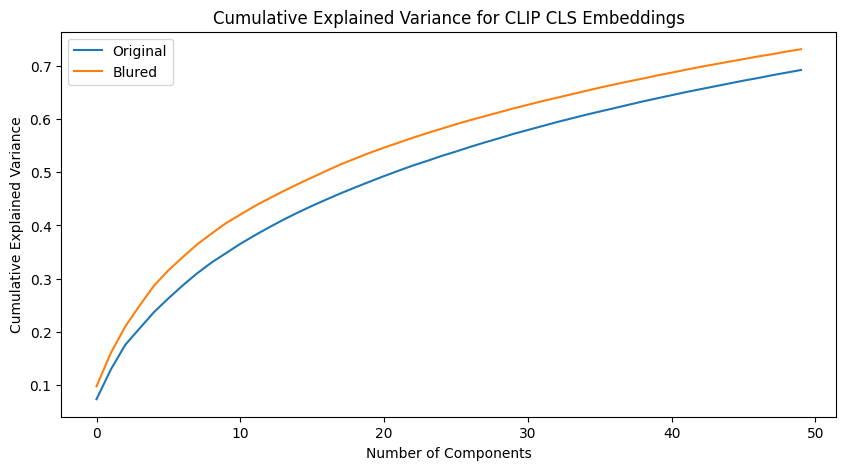

In [33]:
plot_cumulative_variance(cls_orig_evr, cls_blured_evr, suptitle="Cumulative Explained Variance for CLIP CLS Embeddings")

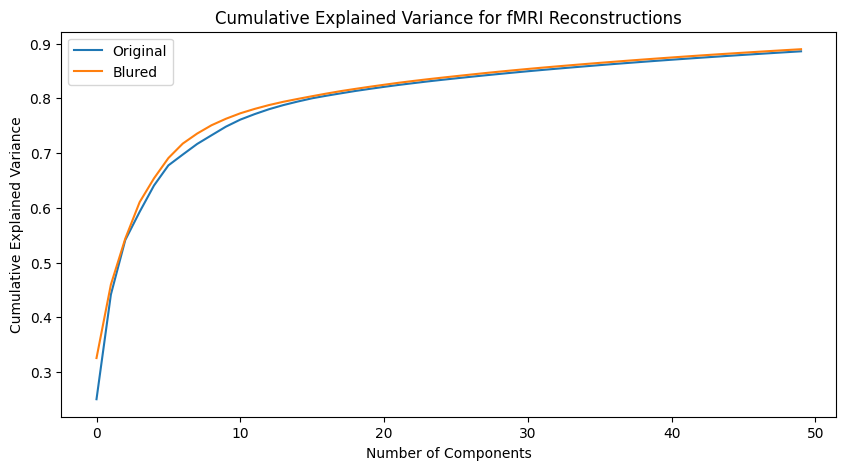

In [34]:
fmri_orig_pca, fmri_orig_comp, fmri_orig_evr = pca(original_fmri_recons, n_components=50)
fmri_blured_pca, fmri_blured_comp, fmri_blured_evr = pca(blured_fmri_recons, n_components=50)
plot_cumulative_variance(fmri_orig_evr, fmri_blured_evr, suptitle="Cumulative Explained Variance for fMRI Reconstructions")